In [96]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [97]:
df = pd.read_csv('ushape.csv')

In [98]:
df.head()

,X,Y,class
0,0.031595,0.986988,0.0
1,2.115098,-0.046244,1.0
2,0.882490,-0.075756,0.0
3,-0.055144,-0.037332,1.0
4,0.829545,-0.539321,1.0


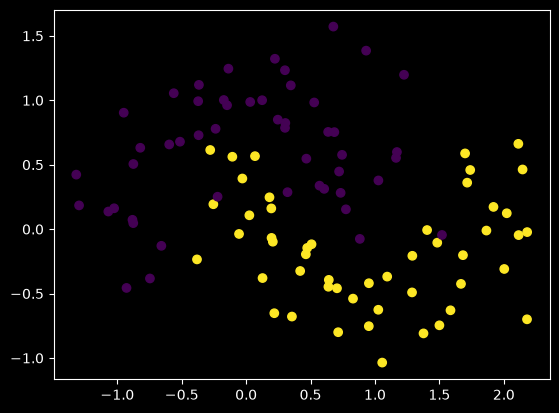

In [99]:
plt.scatter(df['X'],df['Y'],c=df['class'])

In [100]:
X = df.iloc[:,0:2].values
y = df.iloc[:,-1].values

In [101]:
import tensorflow
from tensorflow import keras
from keras import Sequential
from keras.layers import Dense

In [102]:
model = Sequential()

model.add(Dense(2,activation='relu',input_dim=2))
model.add(Dense(1,activation='relu'))

model.summary()

/mnt/c/Users/vinay kumar/Desktop/Deep-Learning/.venv/lib/python3.11/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_9"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_18 (Dense)                │ (None, 2)              │             6 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_19 (Dense)                │ (None, 1)              │             3 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 9 (36.00 B)

 Trainable params: 9 (36.00 B)

 Non-trainable params: 0 (0.00 B)

In [103]:
# Set parameters to 0
model.get_weights()

[array([[-0.69009054, -0.11663663],
        [ 1.1029679 , -0.51556593]], dtype=float32),
 array([0., 0.], dtype=float32),
 array([[0.50539696],
        [0.13483953]], dtype=float32),
 array([0.], dtype=float32)]

In [104]:
initial_weights = model.get_weights()

In [105]:
model.get_weights()

[array([[-0.69009054, -0.11663663],
        [ 1.1029679 , -0.51556593]], dtype=float32),
 array([0., 0.], dtype=float32),
 array([[0.50539696],
        [0.13483953]], dtype=float32),
 array([0.], dtype=float32)]

In [106]:
initial_weights = model.get_weights()

In [107]:
initial_weights[0] = np.ones(model.get_weights()[0].shape)*0.5
initial_weights[1] = np.ones(model.get_weights()[1].shape)*0.5
initial_weights[2] = np.ones(model.get_weights()[2].shape)*0.5
initial_weights[3] = np.ones(model.get_weights()[3].shape)*0.5

In [108]:
model.set_weights(initial_weights)

In [109]:
model.get_weights()

[array([[0.5, 0.5],
        [0.5, 0.5]], dtype=float32),
 array([0.5, 0.5], dtype=float32),
 array([[0.5],
        [0.5]], dtype=float32),
 array([0.5], dtype=float32)]

In [110]:
model.compile(loss='binary_crossentropy',optimizer='adam',metrics=['accuracy'])

In [111]:
history = model.fit(X,y,epochs=100,validation_split=0.2)

Epoch 1/100


3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 60ms/step - accuracy: 0.5125 - loss: 6.6958 - val_accuracy: 0.6000 - val_loss: 4.3009
Epoch 2/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.5125 - loss: 6.6896 - val_accuracy: 0.6000 - val_loss: 4.2953
Epoch 3/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.5125 - loss: 6.6873 - val_accuracy: 0.6000 - val_loss: 4.2894
Epoch 4/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.5125 - loss: 6.5536 - val_accuracy: 0.6000 - val_loss: 4.2840
Epoch 5/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.5125 - loss: 6.4048 - val_accuracy: 0.6000 - val_loss: 4.2786
Epoch 6/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - accuracy: 0.5125 - loss: 6.3925 - val_accuracy: 0.6000 - val_loss: 4.2726
Epoch 7/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.5250 - loss: 6.3772 - val_accuracy: 0.6000 - val_loss: 4.2675
Epoch 8/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.5250 - loss: 6.3655 - val_accuracy: 0.6500 - val_loss: 4.2633
Epoc

In [112]:
model.get_weights()

[array([[0.5592674 , 0.5592674 ],
        [0.44592234, 0.44592234]], dtype=float32),
 array([0.44962588, 0.44962588], dtype=float32),
 array([[0.45372215],
        [0.45372215]], dtype=float32),
 array([0.44551864], dtype=float32)]

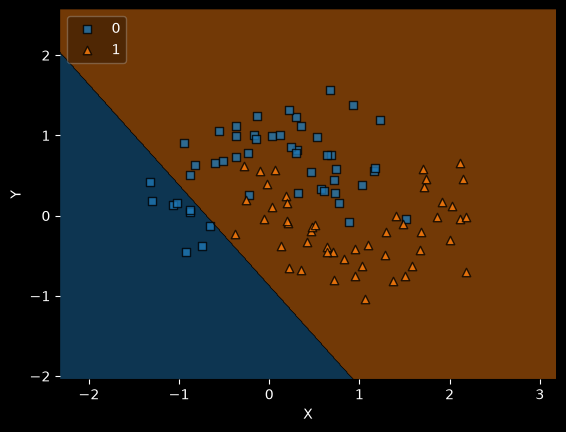

In [113]:
from mlxtend.plotting import plot_decision_regions

class MyClassifier:
    def __init__(self, model):
        self.model = model

    def predict(self, X):
        y_pred = self.model.predict(X, verbose=0)
        return (y_pred >= 0.5).astype(int).ravel()

clf = MyClassifier(model)

plot_decision_regions(
    X,
    y.astype(int),
    clf=clf,
    legend=2
)

plt.xlabel("X")
plt.ylabel("Y")
plt.show()